In [1]:
# Analysis of integrated f1, f1 on test (non-micro), and f1 on KB from different algorithms and datasets
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

algorithms = ['GNN', 'MLP', 'scFoundation', 'scGPT', 'GEARS', 'Linear']

def parse_log_file(log_path):
    """Parse a log file and extract f1 on test, f1 on KB, and integrated f1 values"""
    try:
        with open(log_path, 'r') as f:
            log_content = f.read()
        
        # First try the GNN/MLP format (individual lines without ±)
        f1_test_pattern = re.compile(r'f1 on test:\s*([\d.]+)$', re.MULTILINE)
        f1_test_matches = f1_test_pattern.findall(log_content)
        
        f1_kb_pattern = re.compile(r'f1 on KB:\s*([\d.]+)$', re.MULTILINE)
        f1_kb_matches = f1_kb_pattern.findall(log_content)
        
        integrated_f1_pattern = re.compile(r'integrated f1:\s*([\d.]+)')
        integrated_f1_matches = integrated_f1_pattern.findall(log_content)
        
        if f1_test_matches and f1_kb_matches and integrated_f1_matches:
            # GNN/MLP format - return the last match (final result) for each metric
            f1_test = float(f1_test_matches[-1])
            f1_kb = float(f1_kb_matches[-1]) 
            integrated_f1 = float(integrated_f1_matches[-1])
            return f1_test, f1_kb, integrated_f1
        
        # If that didn't work, try the other methods format (with ± notation)
        f1_test_pm_pattern = re.compile(r'f1 on test:\s*([\d.]+)\s*±')
        f1_test_pm_matches = f1_test_pm_pattern.findall(log_content)
        
        f1_kb_pm_pattern = re.compile(r'f1 on KB:\s*([\d.]+)\s*±')
        f1_kb_pm_matches = f1_kb_pm_pattern.findall(log_content)
        
        integrated_f1_pm_pattern = re.compile(r'integrated F1:\s*([\d.]+)\s*±')
        integrated_f1_pm_matches = integrated_f1_pm_pattern.findall(log_content)
        
        if f1_test_pm_matches and f1_kb_pm_matches and integrated_f1_pm_matches:
            # Other methods format - return the values (usually just one match)
            f1_test = float(f1_test_pm_matches[-1])
            f1_kb = float(f1_kb_pm_matches[-1])
            integrated_f1 = float(integrated_f1_pm_matches[-1])
            return f1_test, f1_kb, integrated_f1
            
        return None, None, None
        
    except Exception as e:
        print(f"Error parsing {log_path}: {e}")
        return None, None, None

def analyze_experiment_folder(folder_path):
    """Analyze all log files in an experiment folder"""
    results = {'GNN': [], 'MLP': [], 'scFoundation': [], 'scGPT': [], 'GEARS': [], 'Linear': []}
    
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        return results
    
    # Get all log files
    log_files = [f for f in os.listdir(folder_path) if f.startswith('log_')]
    
    for log_file in log_files:
        log_path = os.path.join(folder_path, log_file)
        f1_test, f1_kb, integrated_f1 = parse_log_file(log_path)
        
        if f1_test is not None:
            # Determine algorithm type (case-insensitive matching)
            log_file_lower = log_file.lower()
            if 'gnn' in log_file_lower:
                algorithm = 'GNN'
            elif 'mlp' in log_file_lower:
                algorithm = 'MLP'
            elif 'scfoundation' in log_file_lower:
                algorithm = 'scFoundation'
            elif 'scgpt' in log_file_lower:
                algorithm = 'scGPT'
            elif 'gears' in log_file_lower:
                algorithm = 'GEARS'
            elif 'additive' in log_file_lower:
                algorithm = 'Linear'
            else:
                print(f"Unknown algorithm in file: {log_file}")
                continue
            
            results[algorithm].append({
                'f1_test': f1_test,
                'f1_kb': f1_kb,
                'integrated_f1': integrated_f1,
                'log_file': log_file
            })
        else:
            print(f"Could not parse metrics from: {log_file}")
    
    return results

def print_dataset_results(dataset_name, results):
    """Print formatted results for a dataset"""
    print(f"\n=== {dataset_name.upper()} DATASET RESULTS ===")
    for algorithm in algorithms:
        if results[algorithm]:
            df = pd.DataFrame(results[algorithm])
            print(f"\n{algorithm} Algorithm:")
            print(f"Number of runs: {len(df)}")
            print(f"Mean F1 Test: {df['f1_test'].mean():.4f} ± {df['f1_test'].std():.4f}")
            print(f"Mean F1 KB: {df['f1_kb'].mean():.4f} ± {df['f1_kb'].std():.4f}")
            print(f"Mean Integrated F1: {df['integrated_f1'].mean():.4f} ± {df['integrated_f1'].std():.4f}")
            print("Individual results:")
            for i, row in df.iterrows():
                print(f"  Run {i+1}: F1_Test={row['f1_test']:.4f}, F1_KB={row['f1_kb']:.4f}, Integrated_F1={row['integrated_f1']:.4f}")
        else:
            print(f"\nNo results found for {algorithm}")

# Analyze different datasets
datasets = {
    'adamson': 'data_anal/experiment_results/adamson',
    'dixit': 'data_anal/experiment_results/dixit',
    'norman': 'data_anal/experiment_results/norman',
    'precise1k': 'data_anal/experiment_results/precise1k'
}

all_results = {}
for dataset_name, folder_path in datasets.items():
    results = analyze_experiment_folder(folder_path)
    all_results[dataset_name] = results
    print_dataset_results(dataset_name, results)


=== ADAMSON DATASET RESULTS ===

GNN Algorithm:
Number of runs: 5
Mean F1 Test: 0.5396 ± 0.0016
Mean F1 KB: 0.6464 ± 0.0045
Mean Integrated F1: 0.6099 ± 0.0033
Individual results:
  Run 1: F1_Test=0.5406, F1_KB=0.6504, Integrated_F1=0.6128
  Run 2: F1_Test=0.5414, F1_KB=0.6502, Integrated_F1=0.6130
  Run 3: F1_Test=0.5387, F1_KB=0.6478, Integrated_F1=0.6105
  Run 4: F1_Test=0.5373, F1_KB=0.6441, Integrated_F1=0.6075
  Run 5: F1_Test=0.5401, F1_KB=0.6397, Integrated_F1=0.6056

MLP Algorithm:
Number of runs: 5
Mean F1 Test: 0.4535 ± 0.0021
Mean F1 KB: 0.6623 ± 0.0003
Mean Integrated F1: 0.5908 ± 0.0005
Individual results:
  Run 1: F1_Test=0.4515, F1_KB=0.6625, Integrated_F1=0.5905
  Run 2: F1_Test=0.4566, F1_KB=0.6619, Integrated_F1=0.5916
  Run 3: F1_Test=0.4544, F1_KB=0.6622, Integrated_F1=0.5909
  Run 4: F1_Test=0.4529, F1_KB=0.6623, Integrated_F1=0.5908
  Run 5: F1_Test=0.4518, F1_KB=0.6625, Integrated_F1=0.5904

scFoundation Algorithm:
Number of runs: 1
Mean F1 Test: 0.4330 ± nan
M

In [2]:
# Create summary tables and visualizations
import matplotlib.pyplot as plt

# Create summary dataframe
summary_data = []
for dataset_name, results in all_results.items():
    for algorithm in algorithms:  # Use all algorithms, not just GNN and MLP
        if results[algorithm]:
            df = pd.DataFrame(results[algorithm])
            summary_data.append({
                'Dataset': dataset_name.capitalize(),
                'Algorithm': algorithm,
                'Mean_F1_Test': df['f1_test'].mean(),
                'Std_F1_Test': df['f1_test'].std(),
                'Mean_F1_KB': df['f1_kb'].mean(),
                'Std_F1_KB': df['f1_kb'].std(),
                'Mean_Integrated_F1': df['integrated_f1'].mean(),
                'Std_Integrated_F1': df['integrated_f1'].std(),
                'Num_runs': len(df)
            })

summary_df = pd.DataFrame(summary_data)
print("=== SUMMARY TABLE ===")
print(summary_df.to_string(index=False, float_format='%.4f'))

# Pivot tables for easier comparison
print("\n=== F1 TEST COMPARISON ===")
f1_test_pivot = summary_df.pivot(index='Dataset', columns='Algorithm', values='Mean_F1_Test')
print(f1_test_pivot.to_string(float_format='%.4f'))

print("\n=== F1 KB COMPARISON ===")
f1_kb_pivot = summary_df.pivot(index='Dataset', columns='Algorithm', values='Mean_F1_KB')
print(f1_kb_pivot.to_string(float_format='%.4f'))

print("\n=== INTEGRATED F1 COMPARISON ===")
integrated_f1_pivot = summary_df.pivot(index='Dataset', columns='Algorithm', values='Mean_Integrated_F1')
print(integrated_f1_pivot.to_string(float_format='%.4f'))

=== SUMMARY TABLE ===
  Dataset    Algorithm  Mean_F1_Test  Std_F1_Test  Mean_F1_KB  Std_F1_KB  Mean_Integrated_F1  Std_Integrated_F1  Num_runs
  Adamson          GNN        0.5396       0.0016      0.6464     0.0045              0.6099             0.0033         5
  Adamson          MLP        0.4535       0.0021      0.6623     0.0003              0.5908             0.0005         5
  Adamson scFoundation        0.4330          NaN      0.4229        NaN              0.4261                NaN         1
  Adamson        scGPT        0.4560          NaN      0.4048        NaN              0.4195                NaN         1
  Adamson        GEARS        0.4154          NaN      0.4260        NaN              0.4215                NaN         1
  Adamson       Linear        0.2806          NaN      0.1866        NaN              0.2061                NaN         1
    Dixit          GNN        0.4644       0.0031      0.6491     0.0089              0.5750             0.0045         5
  


HUMAN DATASETS RADAR PLOTS


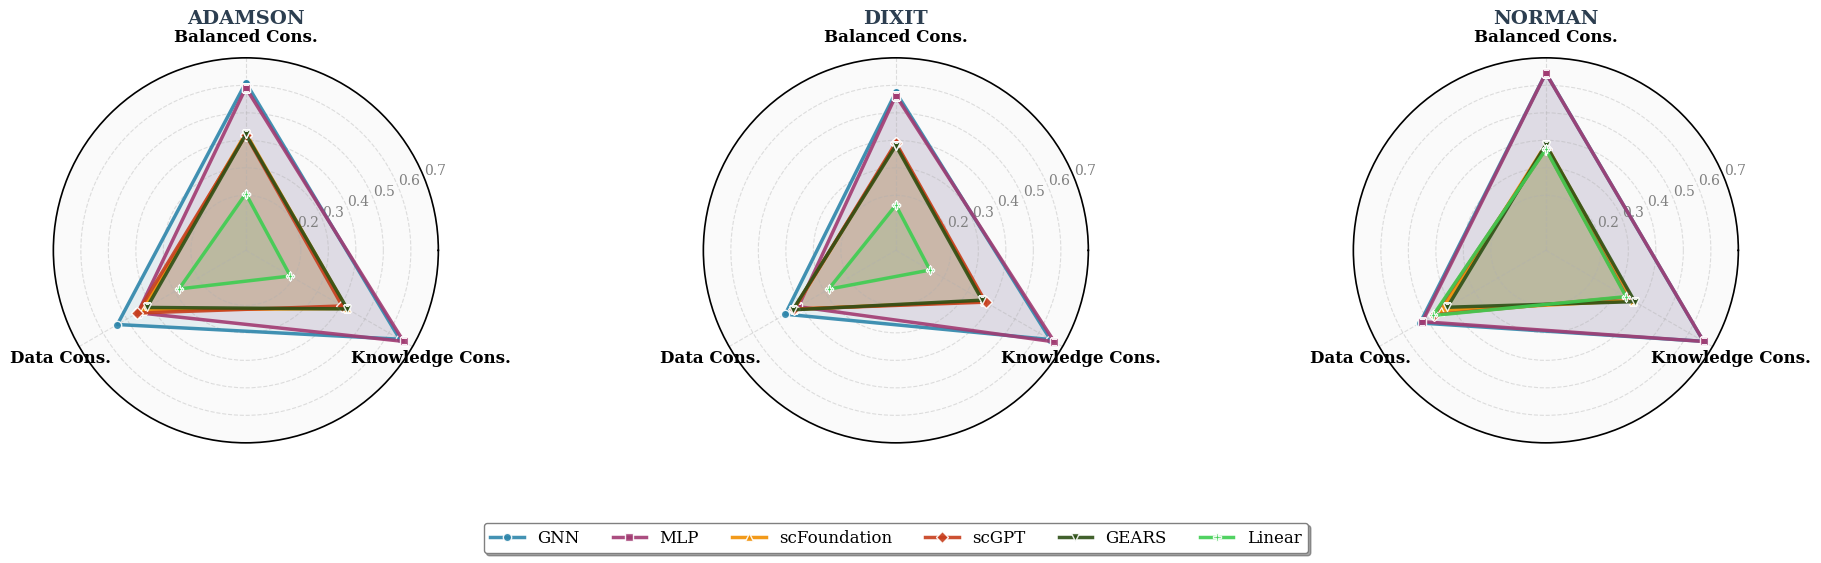

📊 Human datasets plots saved as 'radar_plots_human.pdf' and 'radar_plots_human.png'

PRECISE-1K DATASET RADAR PLOT


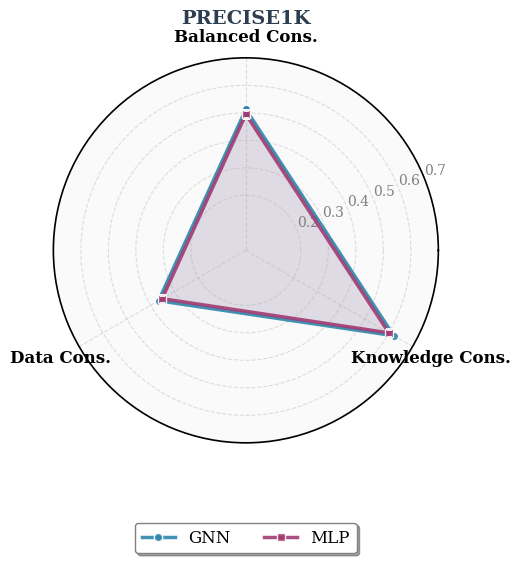

📊 E. coli dataset plots saved as 'radar_plots_precise1k.pdf' and 'radar_plots_precise1k.png'

PUBLICATION SUMMARY: Algorithm Performance Across Datasets

Table 1: Performance comparison across all algorithms and datasets
----------------------------------------------------------------------
Dataset    Algorithm    F1_Test    F1_KB      Integrated_F1
----------------------------------------------------------------------
ADAMSON    GNN          0.540      0.646      0.610        
ADAMSON    MLP          0.453      0.662      0.591        
ADAMSON    scFoundation 0.433      0.423      0.426        
ADAMSON    scGPT        0.456      0.405      0.419        
ADAMSON    GEARS        0.415      0.426      0.421        
ADAMSON    Linear       0.281      0.187      0.206        
DIXIT      GNN          0.464      0.649      0.575        
DIXIT      MLP          0.410      0.665      0.563        
DIXIT      scFoundation 0.428      0.370      0.386        
DIXIT      scGPT        0.428      0.

In [3]:
# Create radar plot visualizations with publication-quality styling
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    # 'font.serif': ['Times New Roman'],
    'axes.linewidth': 1.2,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.shadow': True,
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": r"\usepackage[utf8]{inputenc}\usepackage[T1]{fontenc}",
})

def create_radar_plot(ax, dataset_name, algorithm_values, algorithm_names, category_labels = ['Balanced Cons.', 'Data Cons.', 'Knowledge Cons.']):
    """Create a publication-quality radar plot for one dataset comparing all algorithms"""
    # Define colors for each algorithm
    colors = {
        'GNN': '#2E86AB',         
        'MLP': '#A23B72',         
        'scFoundation': '#F18F01',
        'scGPT': '#C73E1D',       
        'GEARS': '#2D5016',       
        'Linear': "#3ECE51"
    }
    
    # Define markers for each algorithm
    markers = {
        'GNN': 'o',
        'MLP': 's', 
        'scFoundation': '^',
        'scGPT': 'D',
        'GEARS': 'v',
        'Linear': 'P'
    }
    
    # Number of variables
    N = len(category_labels)
    
    # Set specific angles: 90° (top), 210° (left), 330° (right) (converted to radians)
    # Order: Integrated F1 (top), F1 Test (left), F1 KB (right)
    angles = [np.pi/2, 7*np.pi/6, 11*np.pi/6]  # 90°, 210°, 330° in radians
    angles += angles[:1]  # Complete the circle
    
    # Plot each algorithm
    for i, (alg_name, values) in enumerate(zip(algorithm_names, algorithm_values)):
        if len(values) == 3 and all(pd.notna(values)):  # Only plot if we have all 3 values
            # Reorder values to match new angle positions: [Integrated F1, F1 Test, F1 KB]
            plot_values = [values[2], values[0], values[1]]  # integrated_f1, f1_test, f1_kb
            plot_values += plot_values[:1]  # Complete the circle
            
            # Plot algorithm with enhanced styling
            ax.plot(angles, plot_values, markers[alg_name] + '-', linewidth=2.5, label=alg_name,
                    color=colors[alg_name], alpha=0.9, markersize=6, 
                    markerfacecolor=colors[alg_name], markeredgecolor='white', markeredgewidth=1)
            ax.fill(angles, plot_values, alpha=0.1, color=colors[alg_name])
    
    # Enhanced category labels in new order
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(category_labels, fontsize=12, fontweight='bold')
    
    # Set y-axis limits and labels with better formatting
    ax.set_ylim(0.0, 0.7)
    ax.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
    ax.set_yticklabels(['0.2', '0.3', '0.4', '0.5', '0.6', '0.7'], 
                       fontsize=10, color='gray')
    
    # Enhanced grid
    ax.grid(True, alpha=0.4, linewidth=0.8, linestyle='--')
    ax.set_facecolor('#FAFAFA')  # Light background
    
    # Professional title
    ax.set_title(f'{dataset_name.upper()}', size=14, fontweight='bold', 
                pad=25, color='#2C3E50')

# Get datasets that have data for at least one algorithm
available_datasets = list(f1_test_pivot.index)

# Separate eco dataset from other datasets
eco_datasets = [d for d in available_datasets if d.lower() == 'precise1k']
other_datasets = [d for d in available_datasets if d.lower() != 'precise1k']

# Function to create plots for a group of datasets
def create_dataset_plots(datasets_list, title_suffix, filename_suffix):
    if not datasets_list:
        print(f"No datasets found for {title_suffix}")
        return
    
    # Create publication-quality radar plots
    fig = plt.figure(figsize=(20, 5.5))
    fig.patch.set_facecolor('white')
    
    n_datasets = len(datasets_list)
    # Create subplot for each dataset with improved spacing
    for i, dataset in enumerate(datasets_list):
        ax = fig.add_subplot(1, n_datasets, i+1, projection='polar')
        
        # Collect algorithm values and names for this dataset
        algorithm_values = []
        algorithm_names = []
        
        for algorithm in algorithms:
            if algorithm in f1_test_pivot.columns:
                f1_test_val = f1_test_pivot.loc[dataset, algorithm] if algorithm in f1_test_pivot.columns else np.nan
                f1_kb_val = f1_kb_pivot.loc[dataset, algorithm] if algorithm in f1_kb_pivot.columns else np.nan
                integrated_f1_val = integrated_f1_pivot.loc[dataset, algorithm] if algorithm in integrated_f1_pivot.columns else np.nan
                
                # Only include algorithms that have all three metrics
                if pd.notna(f1_test_val) and pd.notna(f1_kb_val) and pd.notna(integrated_f1_val):
                    algorithm_values.append([f1_test_val, f1_kb_val, integrated_f1_val])
                    algorithm_names.append(algorithm)
        
        if algorithm_values:  # Only create plot if we have data
            create_radar_plot(ax, dataset, algorithm_values, algorithm_names)

    # Add a single legend for all subplots if we have any plots
    if algorithm_values:
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), 
                   ncol=len(algorithm_names), fontsize=12, frameon=True, fancybox=True, shadow=True,
                   facecolor='white', edgecolor='gray')

    # Adjust layout with proper spacing
    plt.subplots_adjust(top=0.85, bottom=0.15, left=0.05, right=0.95, wspace=0.3)
    plt.show()

    # Save high-resolution version for publication
    fig.savefig(f'radar_plots_{filename_suffix}.pdf', dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    fig.savefig(f'radar_plots_{filename_suffix}.png', dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')

    print(f"📊 {title_suffix} plots saved as 'radar_plots_{filename_suffix}.pdf' and 'radar_plots_{filename_suffix}.png'")

# Create separate plots for human datasets and eco dataset
if other_datasets:
    print("\n" + "="*80)
    print("HUMAN DATASETS RADAR PLOTS")
    print("="*80)
    create_dataset_plots(other_datasets, "Human datasets", "human")

if eco_datasets:
    print("\n" + "="*80)
    print("PRECISE-1K DATASET RADAR PLOT")
    print("="*80)
    create_dataset_plots(eco_datasets, "E. coli dataset", "precise1k")

# Create summary table for publication
print("\n" + "="*80)
print("PUBLICATION SUMMARY: Algorithm Performance Across Datasets")
print("="*80)

# Create a comprehensive summary table for all algorithms
summary_table = []
for dataset in available_datasets:
    for algorithm in algorithms:
        if algorithm in f1_test_pivot.columns:
            f1_test_val = f1_test_pivot.loc[dataset, algorithm] if not pd.isna(f1_test_pivot.loc[dataset, algorithm]) else None
            f1_kb_val = f1_kb_pivot.loc[dataset, algorithm] if not pd.isna(f1_kb_pivot.loc[dataset, algorithm]) else None
            integrated_f1_val = integrated_f1_pivot.loc[dataset, algorithm] if not pd.isna(integrated_f1_pivot.loc[dataset, algorithm]) else None
            
            if f1_test_val is not None and f1_kb_val is not None and integrated_f1_val is not None:
                summary_table.append([
                    dataset.upper(),
                    algorithm,
                    f"{f1_test_val:.3f}",
                    f"{f1_kb_val:.3f}",
                    f"{integrated_f1_val:.3f}"
                ])

# Print formatted table
summary_df_all = pd.DataFrame(summary_table, columns=[
    'Dataset', 'Algorithm', 'F1_Test', 'F1_KB', 'Integrated_F1'
])

print("\nTable 1: Performance comparison across all algorithms and datasets")
print("-" * 70)
print(f"{'Dataset':<10} {'Algorithm':<12} {'F1_Test':<10} {'F1_KB':<10} {'Integrated_F1':<13}")
print("-" * 70)
for _, row in summary_df_all.iterrows():
    print(f"{row['Dataset']:<10} {row['Algorithm']:<12} {row['F1_Test']:<10} {row['F1_KB']:<10} {row['Integrated_F1']:<13}")